In [243]:
# Decision Tree for Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import (GaussianNB,MultinomialNB,BernoulliNB)
from sklearn.metrics import classification_report, confusion_matrix


In [244]:
# Dataset Preparation
a = input("please insert 1 for iris, 2 for Breast Cancer")
if(a=="1"):
    iris=load_iris()
    X=iris.data
    y=iris.target
    print(iris.feature_names)
    df= pd.DataFrame(X, columns=iris.feature_names)
    print(df.head())
else:
    breast_cancer=load_breast_cancer()
    X=breast_cancer.data
    y=breast_cancer.target
    print(breast_cancer.feature_names)
    df= pd.DataFrame(X, columns=breast_cancer.feature_names)
    print(df.head())

please insert 1 for iris, 2 for Breast Cancer2
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29    

In [245]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [246]:
from sklearn.tree import DecisionTreeClassifier

max_depths = [2, 10]
min_samples_splits = [2, 10]
min_samples_leafs = [2, 10]

results = []

for max_depth in max_depths:
  for min_samples_split in min_samples_splits:
    for min_samples_leaf in min_samples_leafs:
      for criterion in ['gini', 'entropy']:
        for splitter in ['best', 'random']:
          classifier = DecisionTreeClassifier(
            criterion=criterion,
            splitter=splitter,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf)
          classifier.fit(X_train, y_train)
          y_pred = classifier.predict(X_test)
          report = classification_report(y_test, y_pred, output_dict=True)
          cm = confusion_matrix(y_test, y_pred)
          results.append({
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
            "criterion": criterion,
            "splitter": splitter,
            "accuracy": report["accuracy"],
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "f1": report["macro avg"]["f1-score"],
            "confusion matrix": cm
          })
df = pd.DataFrame(results)
df

,max_depth,min_samples_split,min_samples_leaf,criterion,splitter,accuracy,precision,recall,f1,confusion matrix
0,2,2,2,gini,best,0.947368,0.948849,0.943182,0.945697,"[[44, 4], [2, 64]]"
1,2,2,2,gini,random,0.903509,0.920513,0.888258,0.897775,"[[38, 10], [1, 65]]"
2,2,2,2,entropy,best,0.938596,0.938234,0.935606,0.936842,"[[44, 4], [3, 63]]"
3,2,2,2,entropy,random,0.894737,0.923077,0.875000,0.886905,"[[36, 12], [0, 66]]"
4,2,2,10,gini,best,0.938596,0.938234,0.935606,0.936842,"[[44, 4], [3, 63]]"
5,2,2,10,gini,random,0.912281,0.912404,0.907197,0.909495,"[[42, 6], [4, 62]]"
6,2,2,10,entropy,best,0.938596,0.938234,0.935606,0.936842,"[[44, 4], [3, 63]]"
7,2,2,10,entropy,random,0.947368,0.952922,0.940341,0.945332,"[[43, 5], [1, 65]]"
8,2,10,2,gini,best,0.947368,0.948849,0.943182,0.945697,"[[44, 4], [2, 64]]"
9,2,10,2,gini,random,0.903509,0.902032,0.899621,0.900752,"[[42, 6], [5, 61]]"


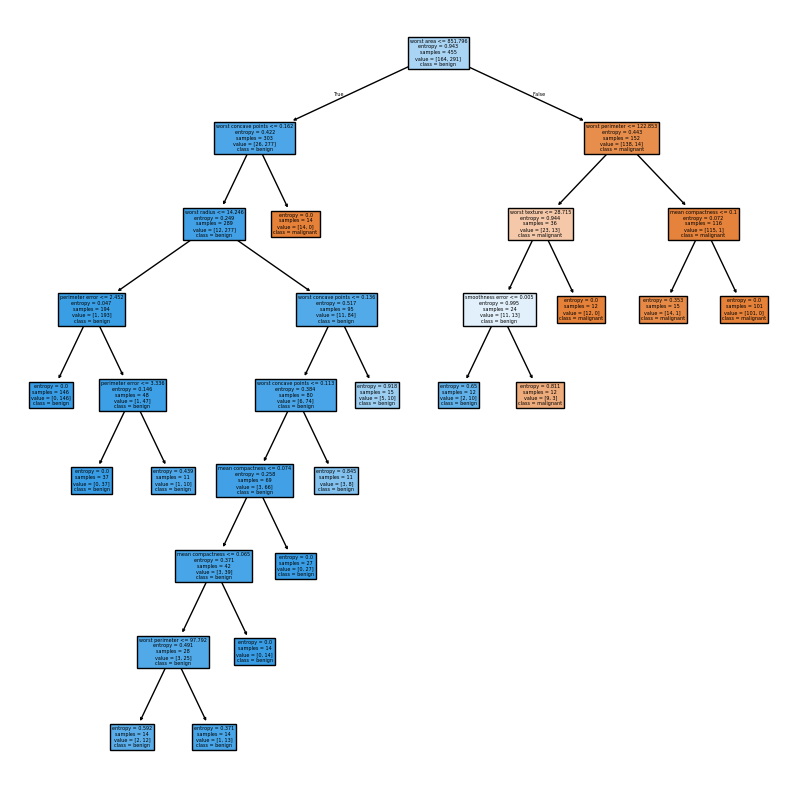

In [247]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
if(a=="1"):
  plot_tree(
      classifier,
      feature_names=iris.feature_names,
      class_names=iris.target_names,
      filled=True
  )
else:
  plot_tree(
      classifier,
      feature_names=breast_cancer.feature_names,
      class_names=breast_cancer.target_names,
      filled=True
  )

plt.show()

In [248]:
smoothing_values = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
results = []

for smoothing in smoothing_values:
    gnb=GaussianNB(var_smoothing = smoothing, priors=None)
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    # print(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        "smoothing" : smoothing,
        "accuracy" : accuracy,
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
        "confusion matrix" : cm
    })
df = pd.DataFrame(results)
df

,smoothing,accuracy,Precision,Recall,F1,confusion matrix
0,1.000000e-09,0.947368,0.952922,0.940341,0.945332,"[[43, 5], [1, 65]]"
1,1.000000e-08,0.912281,0.920635,0.901515,0.908213,"[[40, 8], [2, 64]]"
2,1.000000e-07,0.912281,0.926689,0.898674,0.907468,"[[39, 9], [1, 65]]"
3,1.000000e-06,0.903509,0.920513,0.888258,0.897775,"[[38, 10], [1, 65]]"
4,1.000000e-05,0.903509,0.920513,0.888258,0.897775,"[[38, 10], [1, 65]]"


In [249]:

# from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# scaler = MinMaxScaler()

# X_train_m = scaler.fit_transform(X_train)
# X_test_m = scaler.transform(X_test)
alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []

for alpha in alpha_values:
    mnb = MultinomialNB(alpha=alpha, fit_prior=True)
    mnb.fit(X_train, y_train)
    y_pred = mnb.predict(X_test)
    # print(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        "alpha" : alpha,
        "accuracy" : accuracy,
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
        "confusion matrix" : cm
    })
df = pd.DataFrame(results)
df

,alpha,accuracy,Precision,Recall,F1,confusion matrix
0,0.1,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
1,0.2,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
2,0.3,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
3,0.4,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
4,0.5,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
5,0.6,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
6,0.7,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
7,0.8,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
8,0.9,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"
9,1.0,0.885965,0.917722,0.864583,0.876859,"[[35, 13], [0, 66]]"


BernoulliNB isn't looking at "petal length is 5.1" — it's basically asking "is petal length greater than 0?"

In [250]:
from sklearn.naive_bayes import BernoulliNB

thresholds = np.median(X_train, axis=0)

X_binary_train = (X_train > thresholds).astype(int)
X_binary_test = (X_test > thresholds).astype(int)

In [251]:
alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []

for alpha in alpha_values:
    bnb = BernoulliNB(alpha=alpha, fit_prior=True)
    bnb.fit(X_binary_train, y_train)
    y_pred = mnb.predict(X_binary_test)
    # print(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        "alpha" : alpha,
        "accuracy" : accuracy,
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
        "confusion matrix" : cm
    })
df = pd.DataFrame(results)
df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,alpha,accuracy,Precision,Recall,F1,confusion matrix
0,0.1,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
1,0.2,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
2,0.3,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
3,0.4,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
4,0.5,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
5,0.6,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
6,0.7,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
7,0.8,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
8,0.9,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
9,1.0,0.578947,0.289474,0.5,0.366667,"[[0, 48], [0, 66]]"
